In [1]:
import os
os.chdir('..')
from gpu_management import set_gpus

os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'platform'
set_gpus(1, forcing=True)

GPU usage too high. Retrying in 10 seconds.
GPU usage too high. Retrying in 10 seconds.
GPU usage too high. Retrying in 10 seconds.
GPU usage too high. Retrying in 10 seconds.
GPU usage too high. Retrying in 10 seconds.
GPU usage too high. Retrying in 10 seconds.


In [2]:
from eval import compute_all_rankings

path = "experiments/results/bertram"
drafts, rankings = compute_all_rankings(path, 0)

In [3]:
import numpy as np

pick_pos = np.argmax(
    drafts.packs == drafts.picks[:, :, None],
    axis=2
)
rankings = np.array(rankings)
rankings = np.where(np.isnan(rankings), -1, rankings)
n_picks = (rankings[0,0] >= 0).sum() * 3
n_picks

np.int64(45)

[0.001      0.00107152 0.00114815 0.00123027 0.00131826 0.00141254
 0.00151356 0.00162181 0.0017378  0.00186209 0.00199526 0.00213796
 0.00229087 0.00245471 0.00263027 0.00281838 0.00301995 0.00323594
 0.00346737 0.00371535 0.00398107 0.0042658  0.00457088 0.00489779
 0.00524807 0.00562341 0.0060256  0.00645654 0.00691831 0.0074131
 0.00794328 0.00851138 0.00912011 0.00977237 0.01047129 0.01122018
 0.01202264 0.0128825  0.01380384 0.01479108 0.01584893 0.01698244
 0.01819701 0.01949845 0.02089296 0.02238721 0.02398833 0.02570396
 0.02754229 0.02951209 0.03162278 0.03388442 0.03630781 0.03890451
 0.04168694 0.04466836 0.04786301 0.05128614 0.05495409 0.05888437
 0.06309573 0.0676083  0.0724436  0.07762471 0.08317638 0.08912509
 0.09549926 0.1023293  0.10964782 0.11748976 0.12589254 0.13489629
 0.14454398 0.15488166 0.16595869 0.17782794 0.19054607 0.20417379
 0.21877616 0.23442288 0.25118864 0.26915348 0.28840315 0.30902954
 0.33113112 0.35481339 0.3801894  0.40738028 0.43651583 0.46773

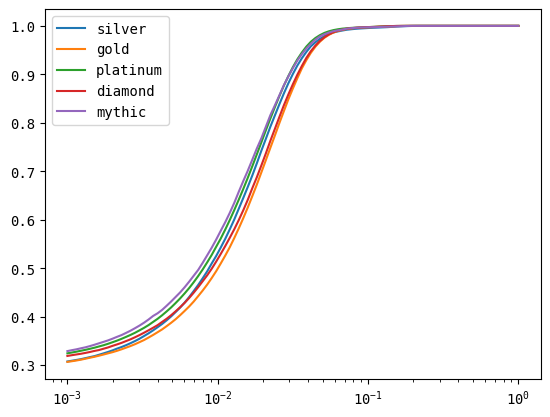

In [10]:
import matplotlib.pyplot as plt
from eval import top_eps_accuracy_score

plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.size'] = 10



rank_dict = {
    0: 'null',
    1: 'bronze',
    2: 'silver',
    3: 'gold',
    4: 'platinum',
    5: 'diamond',
    6: 'mythic',
}

X = np.logspace(-3, 0, 101)
print(X)
for rank in range(1, 7):
    picks = pick_pos[drafts.rank == rank,:n_picks]
    ranks = rankings[drafts.rank == rank,:n_picks]
    if picks.shape[0] == 0:
        continue
    Y = np.array([
        top_eps_accuracy_score(
            picks,
            ranks,
            x
        )
        for x in X
    ])
    plt.plot(X, Y, label=rank_dict[rank])
plt.xscale('log')
plt.legend()
#plt.savefig(f'{path}/accuracy.png', dpi=300, bbox_inches='tight')

In [5]:
picks[1,1], rankings[1,1]

(Array(9, dtype=int32),
 array([ 0.56978774,  0.5956437 ,  0.5373872 ,  0.5928459 ,  0.54817545,
         0.5916089 ,  0.58470476,  0.5691944 ,  0.5846568 ,  0.58170044,
         0.57623965,  0.5367967 ,  0.5670394 ,  0.5741525 , -1.        ],
       dtype=float32))

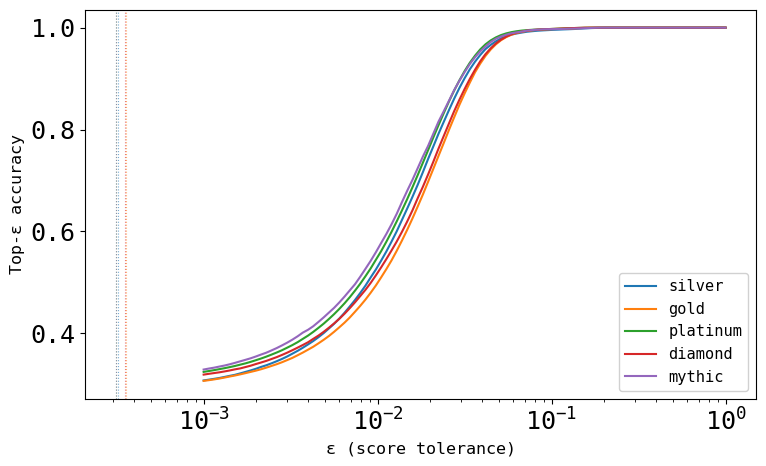

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

s_max = rankings.max(axis=-1)
s_min = np.where(rankings >= 0, rankings, np.inf).min(axis=-1)
eps_10pct = 0.01 * (s_max - s_min)

X = np.logspace(-3, 0, 101)

for i, rank in enumerate(range(2, 7)):
    picks = pick_pos[drafts.rank == rank, :n_picks]
    ranks = rankings[drafts.rank == rank, :n_picks]
    if picks.shape[0] == 0:
        continue
    Y = np.array([top_eps_accuracy_score(picks, ranks, x) for x in X])
    color = colors[i]
    ax.plot(X, Y, label=rank_dict[rank], color=color)

    eps_ref = np.nanmedian(eps_10pct[drafts.rank == rank, :n_picks])
    ax.axvline(eps_ref, color=color, linewidth=0.8, linestyle=':', alpha=0.6)

ax.set_xscale('log')
ax.set_xlabel('ε (score tolerance)', fontsize=12)
ax.set_ylabel('Top-ε accuracy', fontsize=12)
ax.legend(fontsize=11, framealpha=0.9)
fig.tight_layout()
#plt.savefig(f'{path}/accuracy.png', dpi=300, bbox_inches='tight')

1 0.29599765496403524
3 0.6250633234871887


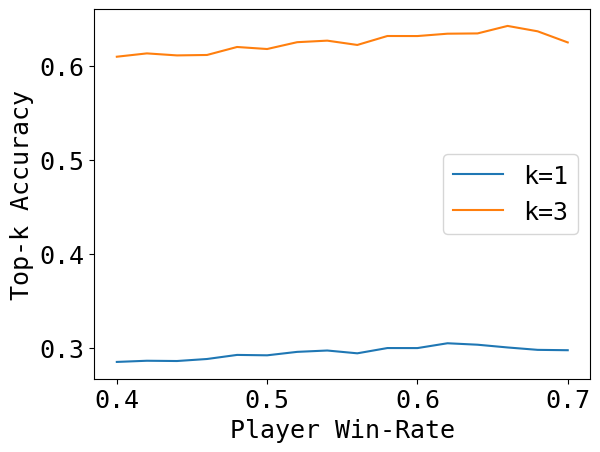

In [7]:
from eval import top_k_accuracy_score

wrs = np.unique(drafts.player_wr)
wrs.sort()
wr_mask = (0.4 <= drafts.player_wr) & (drafts.player_wr <= 0.7)
wrs = wrs[(0.4 <= wrs) & (wrs <= 0.7)]
for k in [1, 3]:
    print(k, top_k_accuracy_score(
        pick_pos[wr_mask,:n_picks].reshape(-1),
        rankings[wr_mask,:n_picks].reshape(-1, 15),
        k=k,
        labels=np.arange(15)
    ))
    means, vars = [], []
    for wr in wrs:
        mask = drafts.player_wr == wr
        m = top_k_accuracy_score(
            pick_pos[mask,:n_picks].reshape(-1),
            rankings[mask,:n_picks].reshape(-1, 15),
            k=k,
            labels=np.arange(15)
        )
        means.append(m)
        # vars.append(v)
    plt.plot(
        wrs,
        means,
        label=f'k={k}'
    )
    # plt.fill_between(
    #     wrs,
    #     np.array(means) - np.sqrt(np.array(vars)),
    #     np.array(means) + np.sqrt(np.array(vars)),
    #     alpha=0.2
    # )
plt.xlabel('Player Win-Rate')
plt.ylabel('Top-k Accuracy')
plt.legend()
# plt.savefig(f'{path}/accuracy_wr.png', dpi=300, bbox_inches='tight')

0.22121526621526624 0.37576386576386583 0.49697913197913196
1 0.29582918621735627
2 0.48806894481571006
3 0.624373982969177


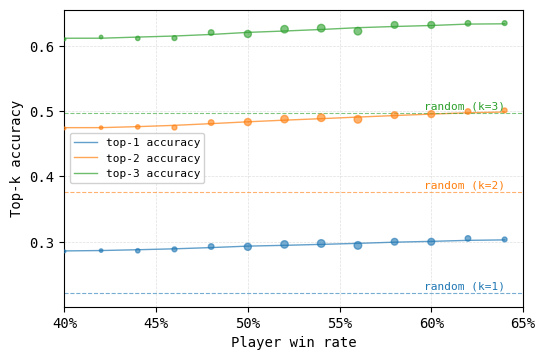

In [11]:
from matplotlib import ticker
import pandas as pd

fig, ax = plt.subplots(figsize=(400/72, 400/72*4/6))

wrs = np.unique(drafts.player_wr)
wrs.sort()
minx, maxx = 0.4, 0.65
wr_mask = (minx <= drafts.player_wr) & (drafts.player_wr <= maxx)
wrs = wrs[(minx <= wrs) & (wrs <= maxx)]

cmap = plt.get_cmap("tab20")

def strict_random_accuracy(k, ps):
    return min(1, k / ps)

def random_accuracy(k, ps=15):
    return np.mean([strict_random_accuracy(k, i) for i in range(1, ps+1)])
print(random_accuracy(1), random_accuracy(2), random_accuracy(3))

for i_k, k in enumerate([1, 2, 3]):
    print(k, top_k_accuracy_score(
        pick_pos[wr_mask,:n_picks].reshape(-1),
        rankings[wr_mask,:n_picks].reshape(-1, 15),
        k=k,
        labels=np.arange(15)
    ))
    
    means = []
    counts = []
    for wr in wrs:
        mask = drafts.player_wr == wr
        m = top_k_accuracy_score(
            pick_pos[mask, :n_picks].reshape(-1),
            rankings[mask, :n_picks].reshape(-1, 15),
            k=k,
            labels=np.arange(15)
        )
        means.append(m)
        counts.append(mask.sum())

    means = np.array(means)
    counts = np.array(counts)

    window = 5
    weights = np.ones(window) / window
    means_smooth = pd.Series(means).rolling(window=window, center=True, min_periods=1).mean().values

    color = cmap(2*i_k)
    ax.scatter(wrs, means, s=counts / counts.max() * 30,
               color=color, alpha=0.6, zorder=3)
    rand = random_accuracy(k)
    ax.axhline(rand, color=color, linewidth=0.8, linestyle='--', alpha=0.6)
    ax.text(wrs.max(), rand + 0.003, f'random (k={k})',
            fontsize=8, color=color, ha='right', va='bottom')
    ax.plot(wrs, means_smooth, label=f'top-{k} accuracy',
            color=color, linewidth=1, alpha=0.7, zorder=2)

ax.set_xlabel('Player win rate', fontsize=10)
ax.set_ylabel('Top-k accuracy', fontsize=10)
ax.set_xlim(wrs.min(), wrs.max())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
ax.set_xticks(np.arange(minx, maxx+0.01, 0.05))
ax.legend(fontsize=8, framealpha=0.9)
fig.tight_layout()
plt.savefig(f'{path}/accuracy_wr.pdf', bbox_inches='tight')

0.22121526621526624 0.37576386576386583 0.49697913197913196


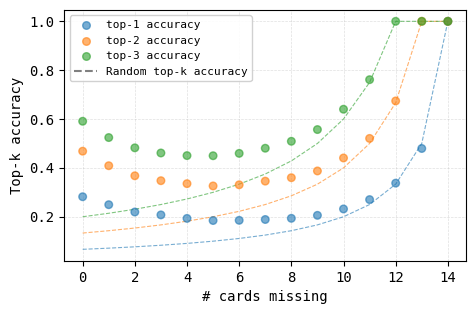

In [28]:
fig, ax = plt.subplots(figsize=(350/72, 350/72*4/6))

print(random_accuracy(1), random_accuracy(2), random_accuracy(3))

npicked = (rankings < 0).sum(axis=-1)

for i_k, k in enumerate([1, 2, 3]):
    X = np.arange(15)
    Y = []
    counts = []
    for x in X:
        mask = npicked == x
        Y.append(top_k_accuracy_score(
            pick_pos[mask].reshape(-1),
            rankings[mask].reshape(-1, 15),
            k=k,
            labels=np.arange(15)
        ))
        counts.append(mask.sum())
    counts = np.array(counts)

    color = cmap(2*i_k)
    ax.scatter(X, Y, s=counts / counts.max() * 30,
               color=color, alpha=0.6, zorder=3, label=f'top-{k} accuracy')
    ax.plot(X, [strict_random_accuracy(k, 15-x) for x in X], color=color, linewidth=0.8, linestyle='--', alpha=0.6)

ax.plot([], [], '--', color='grey', label='Random top-k accuracy')

ax.set_xlabel('# cards missing', fontsize=10)
ax.set_ylabel('Top-k accuracy', fontsize=10)
#ax.set_xlim(wrs.min(), wrs.max())
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
# ax.set_xticks(np.arange(minx, maxx+0.01, 0.05))
ax.legend(fontsize=8, framealpha=0.9)
fig.tight_layout()
plt.savefig(f'{path}/accuracy_pickn.pdf', bbox_inches='tight')

1 0.281994866153282
2 0.468366444487586
3 0.5908669298302379


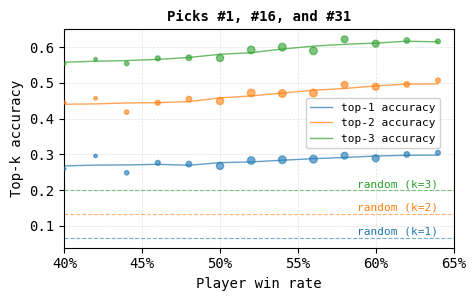

In [36]:
def plot_wr_fixed_size(n_picked, appendix=False):
    fig, ax = plt.subplots(figsize=(350/72, 350/72*0.6))
    
    wrs = np.unique(drafts.player_wr)
    wrs.sort()
    minx, maxx = 0.4, 0.65
    wr_mask = (minx <= drafts.player_wr) & (drafts.player_wr <= maxx)
    wrs = wrs[(minx <= wrs) & (wrs <= maxx)]
    
    for i_k, k in enumerate([1, 2, 3]):
        mask = npicked == n_picked
        print(k, top_k_accuracy_score(
            pick_pos[mask].reshape(-1),
            rankings[mask].reshape(-1, 15),
            k=k,
            labels=np.arange(15)
        ))
        
        means = []
        counts = []
        for wr in wrs:
            mask = drafts.player_wr == wr
            pp = pick_pos[mask, :n_picks]
            rs = rankings[mask, :n_picks]
            mask = npicked[mask] == n_picked
            m = top_k_accuracy_score(
                pp[mask].reshape(-1),
                rs[mask].reshape(-1, 15),
                k=k,
                labels=np.arange(15)
            )
            means.append(m)
            counts.append(mask.sum())
    
        means = np.array(means)
        counts = np.array(counts)
    
        weights = np.ones(window) / window
        means_smooth = pd.Series(means).rolling(window=5, center=True, min_periods=1).mean().values
    
        color = cmap(2*i_k)
        ax.scatter(wrs, means, s=counts / counts.max() * 30,
                   color=color, alpha=0.6, zorder=3)
        rand = strict_random_accuracy(k, 15-n_picked)
        ax.axhline(rand, color=color, linewidth=0.8, linestyle='--', alpha=0.6)
        ax.text(wrs.max(), rand + 0.003, f'random (k={k})',
                fontsize=8, color=color, ha='right', va='bottom')
        ax.plot(wrs, means_smooth, label=f'top-{k} accuracy',
                color=color, linewidth=1, alpha=0.7, zorder=2)

    if not appendix or (n_picked % 3) == 2:
        ax.set_xlabel('Player win rate', fontsize=10)
    ax.set_ylabel('Top-k accuracy', fontsize=10)
    ax.set_xlim(wrs.min(), wrs.max())
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
    ax.set_xticks(np.arange(minx, maxx+0.01, 0.05))
    if appendix:
        ax.legend(fontsize=8, framealpha=0.9, loc='lower left')
    else:
        ax.legend(fontsize=8, framealpha=0.9, bbox_to_anchor=(0.98, 0.57), loc='center right')
    fig.tight_layout()
    ax.set_title(f'Picks #{n_picked + 1}, #{n_picked+16}, and #{n_picked+31}', fontsize=10, fontweight='bold')
    plt.savefig(f'{path}/accuracy_wr_{n_picked}{'_appendix' if appendix else ''}.pdf', bbox_inches='tight')

plot_wr_fixed_size(0)

1 0.281994866153282
2 0.468366444487586
3 0.5908669298302379
1 0.2493798399447788
2 0.40893893310899715
3 0.524213205634289
1 0.21946116180245476
2 0.36769559308872063
3 0.4821286050173645
1 0.20759723031126642
2 0.34763476347634764
3 0.4610539485321081
1 0.1932095170301344
2 0.3355119825708061
3 0.4503764101900386
1 0.18458120321836105
2 0.326150262085032
3 0.4497724282232145
1 0.18540089303047952
2 0.33083112232791906
3 0.45945771047693007
1 0.18876593541707112
2 0.34577967600681636
3 0.48046765460859814
1 0.19359779115166417
2 0.35986539830453634
3 0.5089410901874502
1 0.20576371362626458
2 0.38751914407126986
3 0.5569145149809098
1 0.23195064604499666
2 0.44060484479820533
3 0.6401130309109342
1 0.2702603593692703
2 0.5206755969714618
3 0.7611682736901141
1 0.3375827778856317
2 0.6741301581138506
3 1.0
1 0.4794753985202442
2 1.0
3 1.0
1 1.0
2 1.0
3 1.0


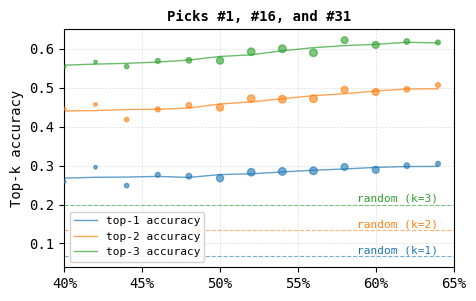

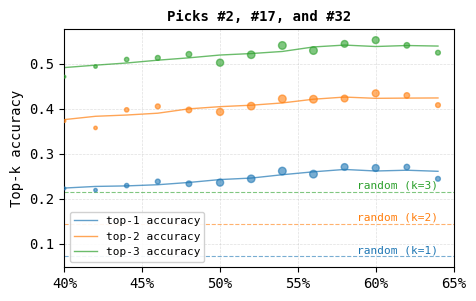

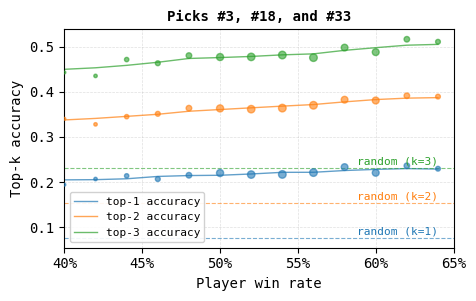

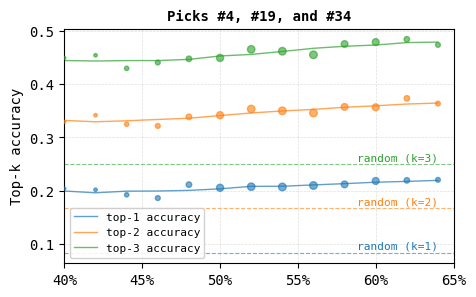

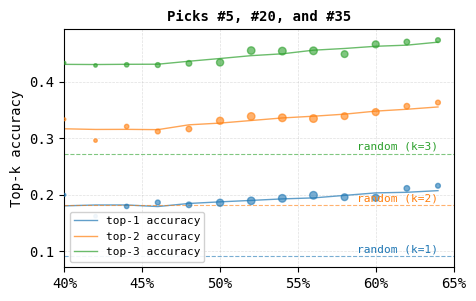

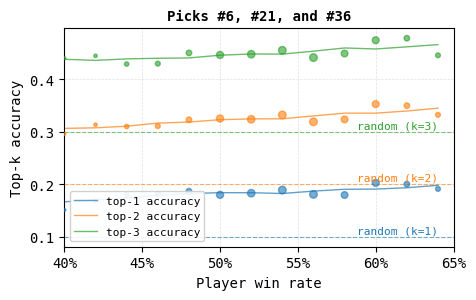

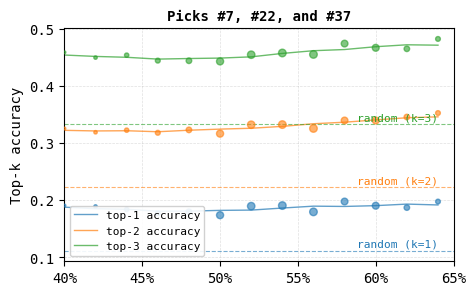

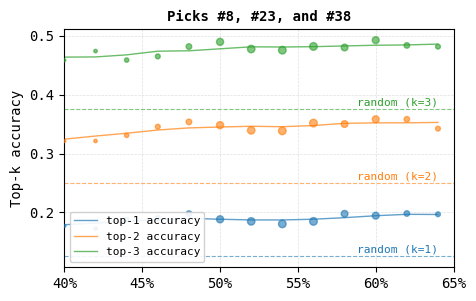

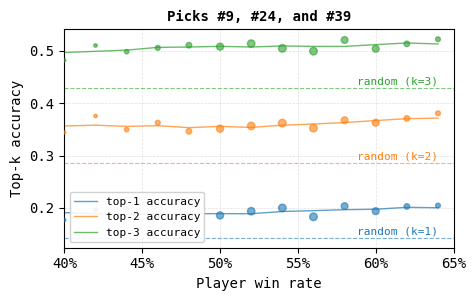

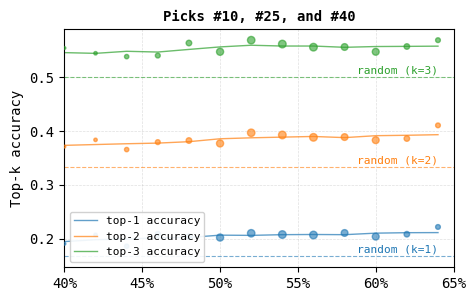

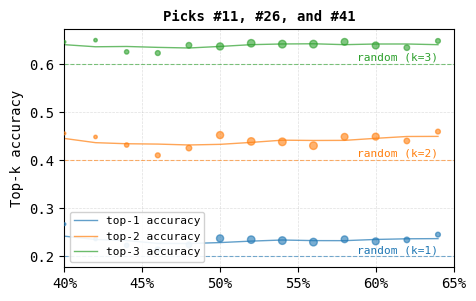

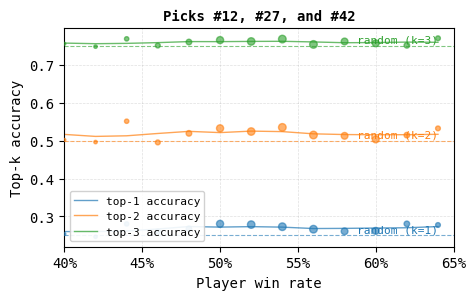

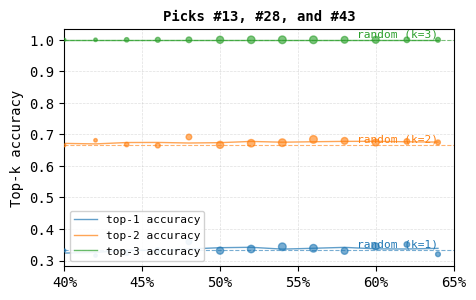

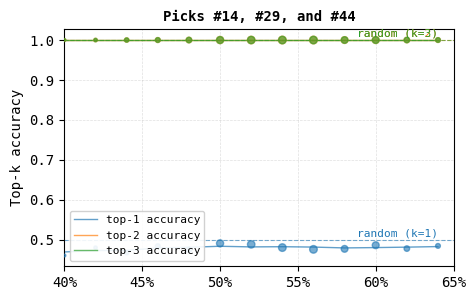

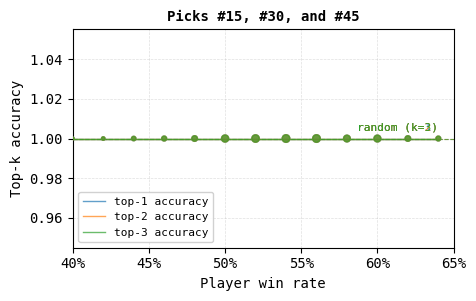

In [37]:
for n_picked in range(15):
    plot_wr_fixed_size(n_picked, appendix=True)